In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('../notebooks/data/busan_youth_v4.csv', index_col='Unnamed: 0')
df.head()

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업규모구조,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,3257296.0,1689.0,0.007168,5.764203,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,3326347.0,1035.0,0.014533,7.266690,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,2994355.0,1284.0,0.012316,3.900020,289.682121,39427.386,-0.390397,-3.492136


In [3]:
df.columns

Index(['연도', '행정구역', '연앙인구수(천명)', '재정자립도(%)', '통계방식변경', '상용월평균급여(원)',
       '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조', '지역내총생산(십억원)',
       '청년_19_29_증감률(%)', '청년_30_39_증감률(%)'],
      dtype='object')

In [4]:
# 변수 분류
# 종속변수
y_cols = df[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = df[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조']]

# 독립변수(통계방식변경)
x_cols_control = df[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조', '통계방식변경']]


# 통제변수
meta_cols = df[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = df[['연도', '행정구역']]

---

# Z값 구하기

In [5]:
# 연도별 전국 평균 표준편차 계산
# y, x, 연도만 사용
tmp = pd.concat(
    [
        group_cols[['연도', '행정구역']],
        y_cols,
        x_cols,
        meta_cols
    ],
    axis=1
)
targets = list(y_cols.columns) + list(x_cols.columns) + list(meta_cols.columns)

# 연도별 전국 평균·표준편차
year_stats = (
    tmp
    .groupby('연도')[targets]
    .agg(['mean', 'std'])
)


# 연도별 전국 기준 Z값 계산
tmp_z = tmp.copy()

for col in targets:
    mean = tmp_z.groupby('연도')[col].transform('mean')
    std  = tmp_z.groupby('연도')[col].transform('std')

    tmp_z[col + '_z'] = (tmp_z[col] - mean) / std

z_cols = [c + "_z" for c in targets]

# z값 검증_연도별 Z 평균 ≈ 0 ?
tmp_z.groupby('연도')[z_cols].mean()

# z값 검증: 연도별 Z 표준편차 ≈ 1 ?
tmp_z.groupby('연도')[z_cols].std()

# 부산 Z값 구하기
z_cols_busan = tmp_z[tmp_z['행정구역'] == '부산광역시'][['연도'] + z_cols]
z_cols_busan

,연도,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업규모구조_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
7,2016,-0.579380,-0.239824,-0.752048,0.203951,-0.724384,-0.871036,0.244947,0.142879,0.453596,-0.127948
24,2017,-0.522525,-0.426332,-0.743358,0.186550,-0.697547,-0.857878,0.233573,0.133287,0.516095,-0.157955
41,2018,-0.655244,-0.457192,-0.616407,0.145828,-0.692370,-0.856537,0.224377,0.122626,0.532964,-0.155544
58,2019,-0.881924,-0.507070,-0.654720,-0.007670,-0.673343,-0.831291,0.202989,0.112518,0.505363,-0.146210
75,2020,-0.749982,-0.193108,-0.485619,0.074376,-0.653049,-0.824099,0.178028,0.104236,0.502001,-0.158862
92,2021,-0.148821,-0.278071,-0.394760,-0.007670,-0.707601,-0.801185,0.159529,0.096783,0.389980,-0.155654
109,2022,-0.658018,-0.026412,-0.511767,0.155662,-0.692672,-0.807214,0.143142,0.089801,0.374920,-0.141809
126,2023,-0.402256,-0.102928,-0.416512,0.116384,-0.674306,-0.843869,0.128063,0.084120,0.309353,-0.152871
143,2024,-0.924423,-0.657936,-0.473356,0.078923,-0.561149,-0.836980,0.108004,0.078339,0.360497,-0.165156


In [6]:
# 부산 z값 기술통계값 
z_cols_busan.describe()

,연도,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업규모구조_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,2020.000000,-0.613619,-0.320986,-0.560950,0.105148,-0.675158,-0.836676,0.180295,0.107177,0.438308,-0.151334
std,2.738613,0.240070,0.205219,0.135050,0.077307,0.047528,0.023429,0.049050,0.022376,0.081267,0.011148
min,2016.000000,-0.924423,-0.657936,-0.752048,-0.007670,-0.724384,-0.871036,0.108004,0.078339,0.309353,-0.165156
25%,2018.000000,-0.749982,-0.457192,-0.654720,0.074376,-0.697547,-0.856537,0.143142,0.089801,0.374920,-0.157955
50%,2020.000000,-0.655244,-0.278071,-0.511767,0.116384,-0.692370,-0.836980,0.178028,0.104236,0.453596,-0.155544
75%,2022.000000,-0.522525,-0.193108,-0.473356,0.155662,-0.673343,-0.824099,0.224377,0.122626,0.505363,-0.146210
max,2024.000000,-0.148821,-0.026412,-0.394760,0.203951,-0.561149,-0.801185,0.244947,0.142879,0.532964,-0.127948


In [7]:
# 행정구역별/연도별 전체 z값 구하기 
z_cols_all = tmp_z[['행정구역', '연도'] + z_cols]
z_cols_all

,행정구역,연도,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업규모구조_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
0,강원특별자치도,2016,-0.119064,-0.284835,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361
1,경기도,2016,0.014971,-0.045046,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738
2,경상남도,2016,-0.359782,-0.291791,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773
3,경상북도,2016,-0.370028,-0.304519,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230
4,광주광역시,2016,-0.426919,-0.547518,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549
...,...,...,...,...,...,...,...,...,...,...,...,...
148,전라남도,2024,-0.518022,0.005958,-0.162273,-0.358235,0.406573,1.182580,-0.306634,-0.359256,-1.137119,-0.260644
149,전북특별자치도,2024,-0.972103,-0.271329,-0.882036,-0.251928,0.669217,0.598846,-0.265283,-0.374308,-1.201416,-0.468302
150,제주특별자치도,2024,-0.976313,-0.769400,-1.450222,-0.460300,-0.968725,2.406320,-0.679208,-0.692800,-0.442855,-0.690959
151,충청남도,2024,1.911852,0.311186,1.394857,-0.253783,0.610334,0.275757,-0.256486,-0.259994,-0.562780,0.000253


In [8]:
# 행정구역별 Z분포 요약(위험도 비교) - 30대 
tmp_z.groupby('행정구역')['청년_30_39_증감률(%)_z'].describe()

,count,mean,std,min,25%,50%,75%,max
행정구역,,,,,,,,
강원특별자치도,9.0,0.108228,0.372285,-0.353001,-0.275186,0.090351,0.444217,0.631779
경기도,9.0,0.796413,0.576498,-0.045046,0.433617,0.778997,1.151131,1.662441
경상남도,9.0,-1.066405,0.693290,-1.813716,-1.701575,-1.428222,-0.366213,-0.211247
경상북도,9.0,-0.860160,0.501164,-1.525823,-1.347170,-0.802525,-0.397638,-0.304519
광주광역시,9.0,-0.430777,0.258199,-0.705553,-0.547518,-0.520556,-0.487049,0.123046
대구광역시,9.0,-0.055003,0.470962,-0.420225,-0.377181,-0.260962,0.112126,0.884987
대전광역시,9.0,0.086394,0.619343,-0.527579,-0.440297,-0.055763,0.612449,1.170668
부산광역시,9.0,-0.320986,0.205219,-0.657936,-0.457192,-0.278071,-0.193108,-0.026412
서울특별시,9.0,0.322910,0.582264,-0.431266,-0.246412,0.280829,0.791670,1.058663


In [9]:
# 행정구역별 Z분포 요약(위험도 비교) - 20대 
tmp_z.groupby('행정구역')['청년_19_29_증감률(%)_z'].describe()

,count,mean,std,min,25%,50%,75%,max
행정구역,,,,,,,,
강원특별자치도,9.0,-0.222406,0.455490,-0.769281,-0.516152,-0.450210,0.206627,0.430523
경기도,9.0,0.636098,0.563275,-0.098518,0.246560,0.615856,0.930361,1.477147
경상남도,9.0,-0.755761,0.455449,-1.537010,-0.984428,-0.791847,-0.359782,-0.133222
경상북도,9.0,-0.633514,0.429613,-1.253624,-0.855252,-0.747594,-0.401199,0.255361
광주광역시,9.0,0.066078,0.855944,-0.669863,-0.586997,-0.114938,0.158246,1.984040
대구광역시,9.0,-0.453643,0.238310,-0.976568,-0.553662,-0.344089,-0.321148,-0.201089
대전광역시,9.0,0.178395,0.538274,-0.517939,-0.220938,-0.013189,0.654250,1.000479
부산광역시,9.0,-0.613619,0.240070,-0.924423,-0.749982,-0.655244,-0.522525,-0.148821
서울특별시,9.0,0.221837,0.521984,-0.528923,-0.151338,0.192093,0.426651,1.087670


---

# 시각화

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


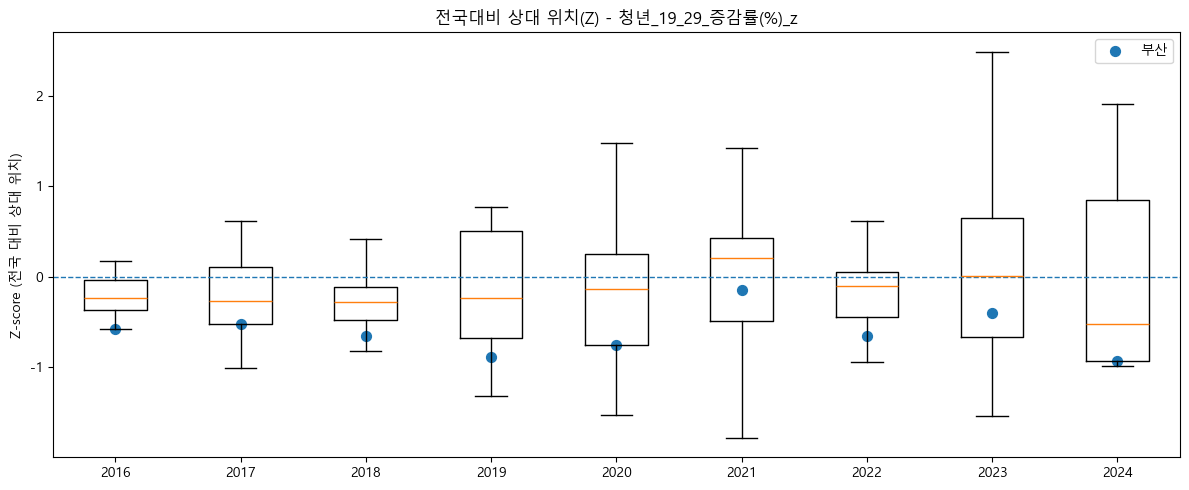

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


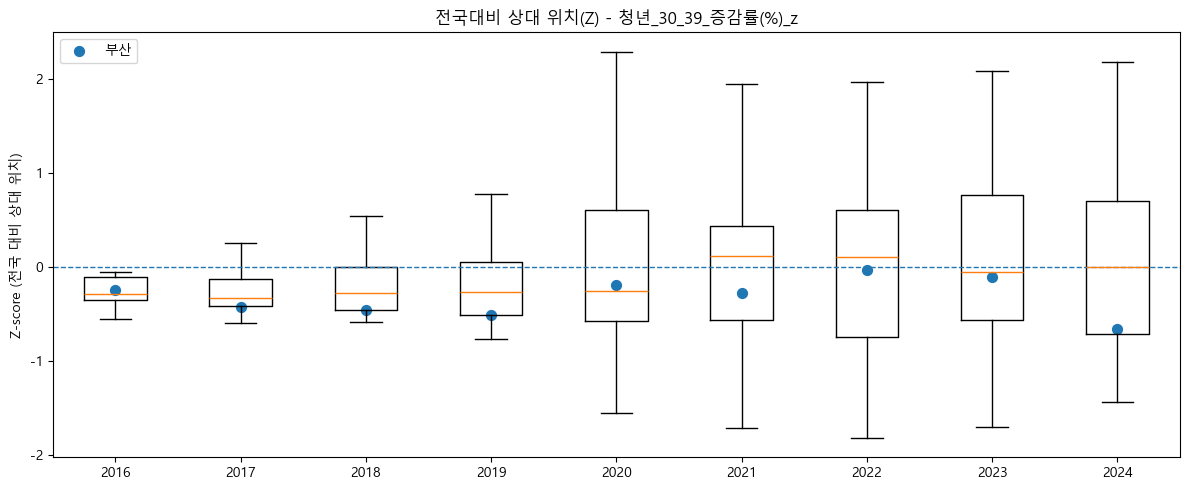

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


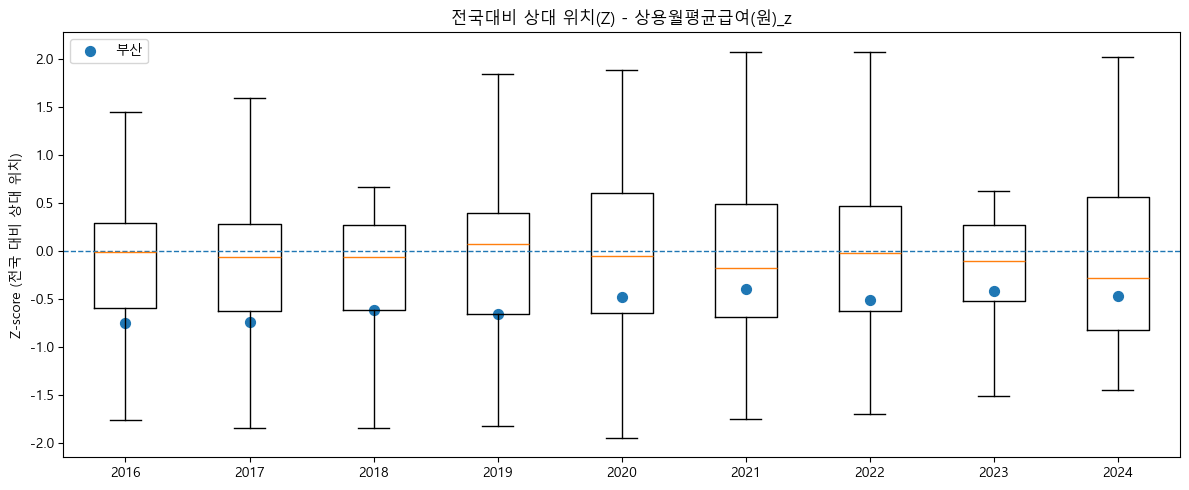

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


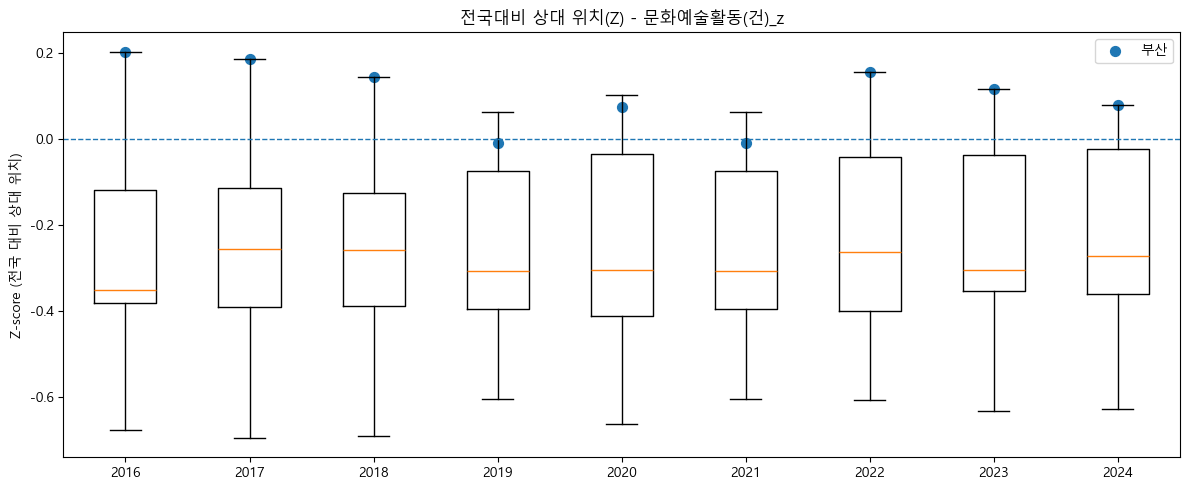

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


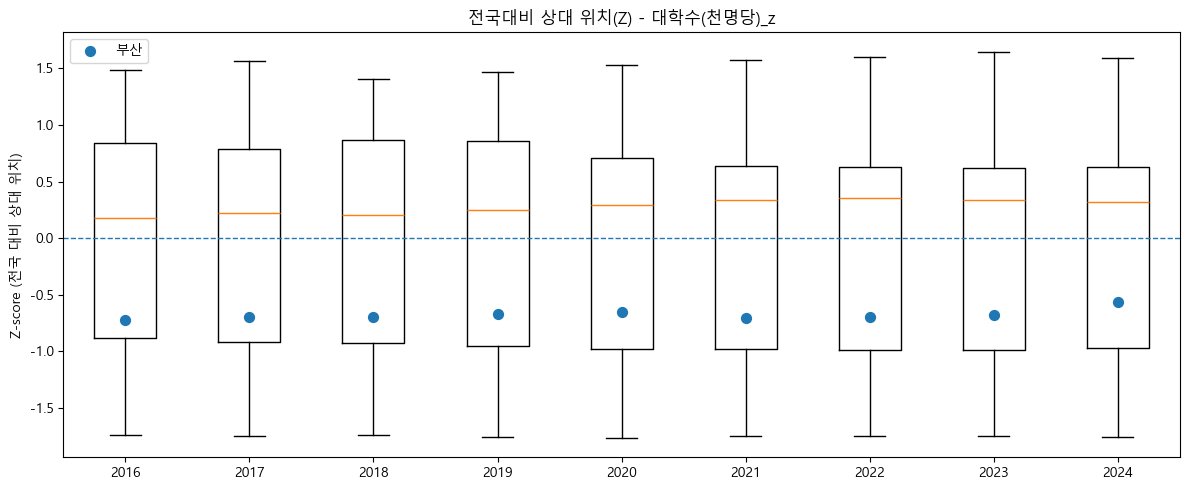

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


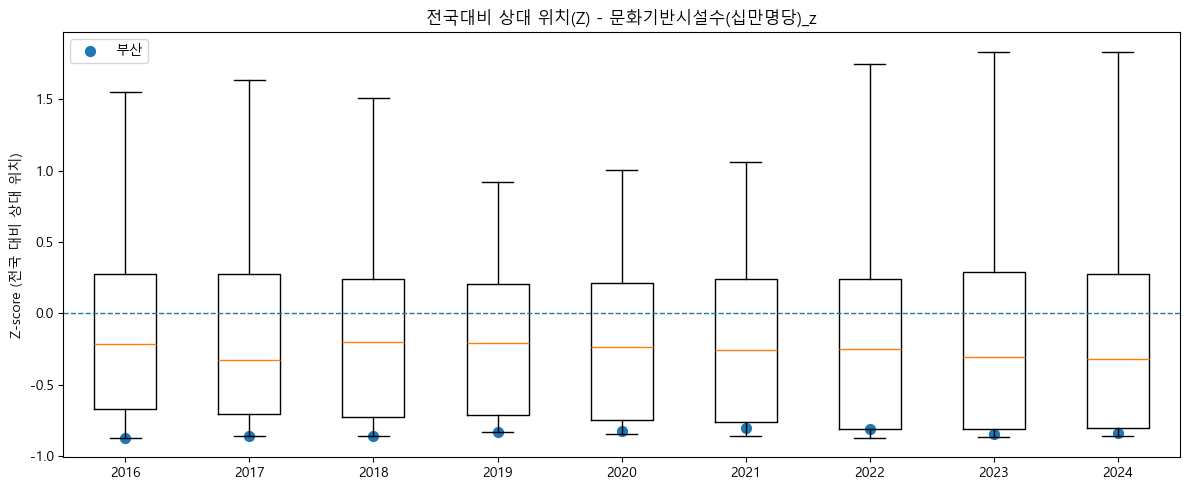

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


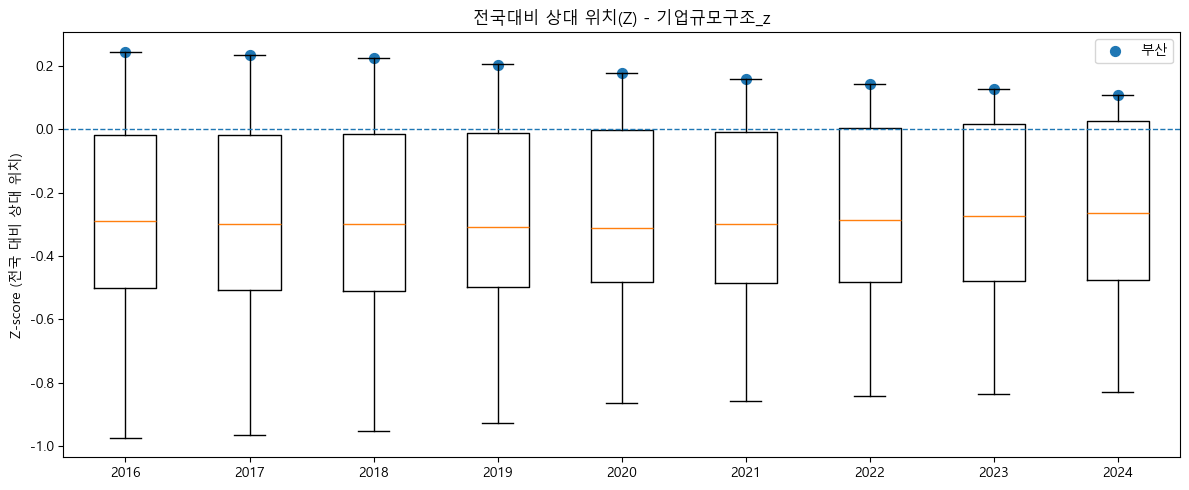

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


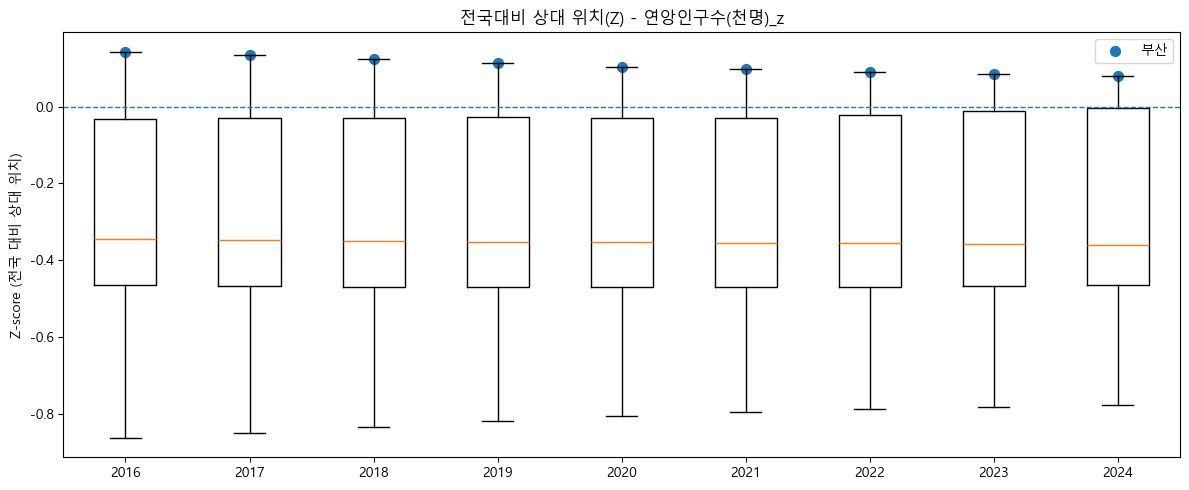

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


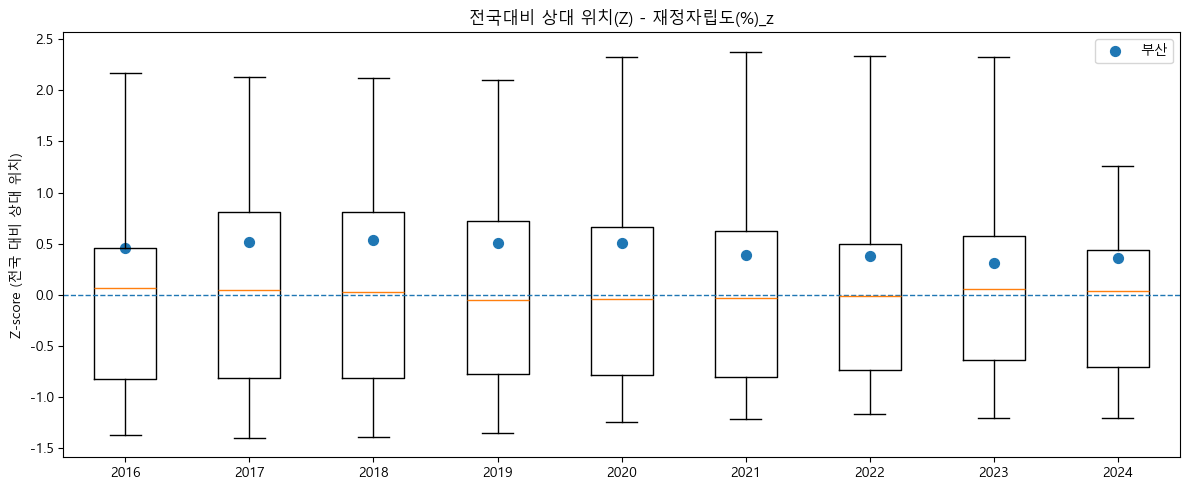

C:\Users\Dell5371\AppData\Local\Temp\ipykernel_26900\1676994302.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_year, labels=years, showfliers=showfliers)


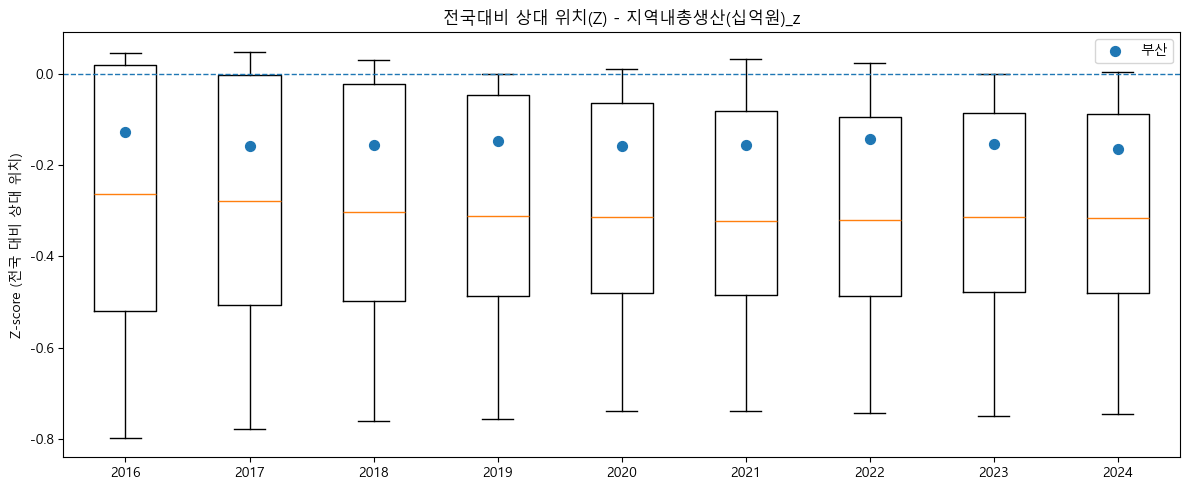

In [10]:
# 연도별 박스플롯(전국분포) + 부산 점
def boxplot_yearly_with_busan_point(
    df_z,
    z_cols,
    *,
    year_col="연도",
    region_col="행정구역",
    busan_name="부산광역시",
    showfliers=False,
    title=None
):
    # 0) 컬럼 체크
    need = [year_col, region_col, z_cols]
    missing = [c for c in need if c not in df_z.columns]
    if missing:
        raise ValueError(f"df_z에 없는 컬럼: {missing}")

    # 1) 연도 목록
    years = sorted(df_z[year_col].dropna().unique())

    # 2) 박스플롯 데이터(전국 분포) + 부산 점
    data_by_year = []
    busan_points = []

    for y in years:
        df_y = df_z[df_z[year_col] == y]

        # 전국 분포
        vals = df_y[z_cols].dropna().astype(float).values
        data_by_year.append(vals)

        # 부산 값
        s = df_y[df_y[region_col] == busan_name][z_cols]
        busan_points.append(float(s.iloc[0]) if len(s) else np.nan)

    # 3) 플롯
    plt.figure(figsize=(12, 5))
    plt.boxplot(data_by_year, labels=years, showfliers=showfliers)
    plt.scatter(np.arange(1, len(years) + 1), busan_points, s=50, label="부산")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.ylabel("Z-score (전국 대비 상대 위치)")
    plt.title(title if title else f"연도별 박스플롯 + 부산 점: {z_cols}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for col in z_cols:   # 예: 8개 특성 z컬럼 리스트
    boxplot_yearly_with_busan_point(
        df_z=tmp_z,
        z_cols=col,
        title=f"전국대비 상대 위치(Z) - {col}"
    )

In [11]:
tmp_z

,연도,행정구역,청년_19_29_증감률(%),청년_30_39_증감률(%),상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업규모구조,연앙인구수(천명),...,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업규모구조_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
0,2016,강원특별자치도,1.149646,-2.070627,3023906.0,1444.0,0.012368,13.734520,351.305988,1536.2750,...,-0.119064,-0.284835,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361
1,2016,경기도,1.820153,-0.773010,3328379.0,3925.0,0.006235,4.028943,2230.077238,12509.4835,...,0.014971,-0.045046,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738
2,2016,경상남도,-0.054546,-2.108272,3257296.0,1689.0,0.007168,5.764203,652.882347,3348.2515,...,-0.359782,-0.291791,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773
3,2016,경상북도,-0.105801,-2.177146,3326347.0,1035.0,0.014533,7.266690,549.557763,2683.4775,...,-0.370028,-0.304519,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230
4,2016,광주광역시,-0.390397,-3.492136,2994355.0,1284.0,0.012316,3.900020,289.682121,1461.5310,...,-0.426919,-0.547518,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,-5.046648,-0.016089,4034870.0,1438.0,0.010601,13.390429,504.474684,1792.3250,...,-0.518022,0.005958,-0.162273,-0.358235,0.406573,1.182580,-0.306634,-0.359256,-1.137119,-0.260644
149,2024,전북특별자치도,-5.533847,-0.308514,3736595.0,1839.0,0.011483,10.794448,537.972610,1741.6360,...,-0.972103,-0.271329,-0.882036,-0.251928,0.669217,0.598846,-0.265283,-0.374308,-1.201416,-0.468302
150,2024,제주특별자치도,-5.538364,-0.833774,3501134.0,1053.0,0.005979,18.832645,202.652238,669.0510,...,-0.976313,-0.769400,-1.450222,-0.460300,-0.968725,2.406320,-0.679208,-0.692800,-0.442855,-0.690959
151,2024,충청남도,-2.439551,0.305802,4680157.0,1832.0,0.011286,9.357610,545.099532,2126.6115,...,1.911852,0.311186,1.394857,-0.253783,0.610334,0.275757,-0.256486,-0.259994,-0.562780,0.000253


In [12]:
tmp_z.columns

Index(['연도', '행정구역', '청년_19_29_증감률(%)', '청년_30_39_증감률(%)', '상용월평균급여(원)',
       '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조', '연앙인구수(천명)',
       '재정자립도(%)', '지역내총생산(십억원)', '청년_19_29_증감률(%)_z', '청년_30_39_증감률(%)_z',
       '상용월평균급여(원)_z', '문화예술활동(건)_z', '대학수(천명당)_z', '문화기반시설수(십만명당)_z',
       '기업규모구조_z', '연앙인구수(천명)_z', '재정자립도(%)_z', '지역내총생산(십억원)_z'],
      dtype='object')

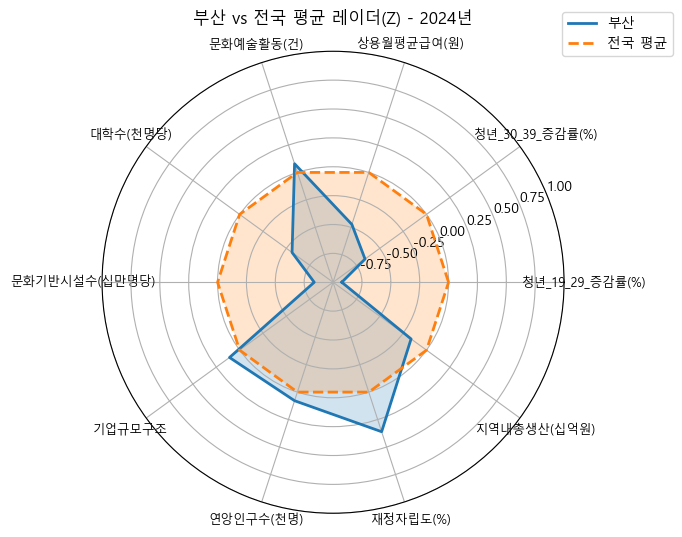

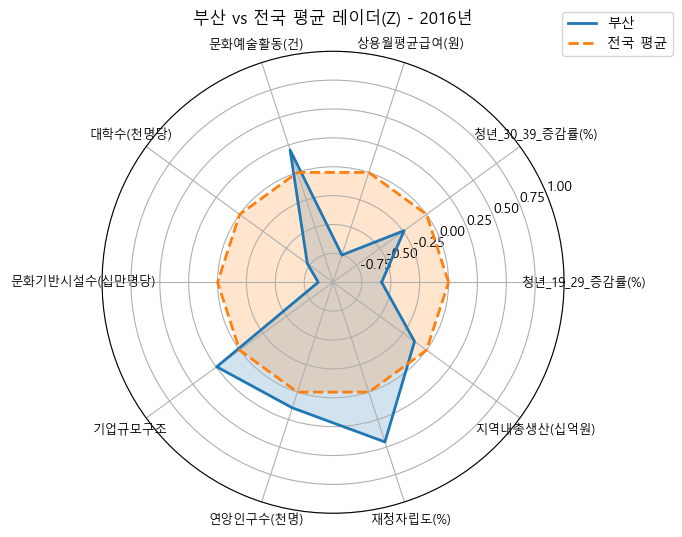

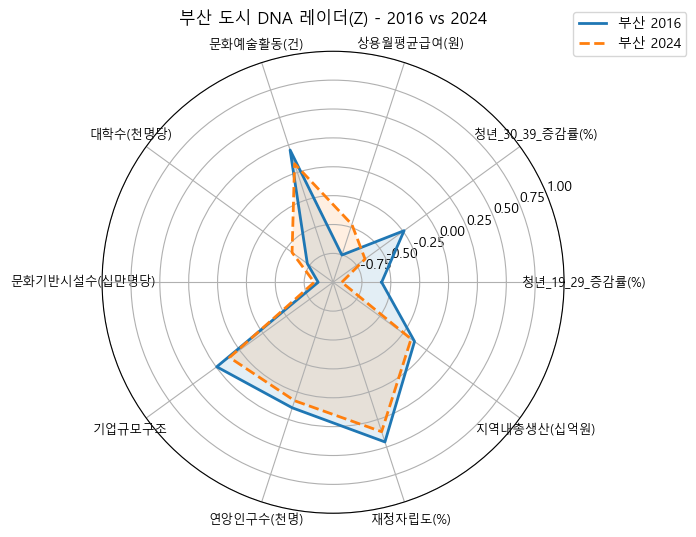

In [13]:
# 레이더차트 
# 0) 공용 유틸 
def _check_cols(df, cols, df_name="df"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name}에 없는 컬럼: {missing}")

def _get_region_vals(df, *, year, z_cols, year_col, region_col, region_name):
    sub = df[df[year_col] == year]
    if sub.empty:
        raise ValueError(f"{year}년 데이터가 없습니다.")
    row = sub[sub[region_col] == region_name]
    if row.empty:
        cand = sorted(df[region_col].astype(str).unique().tolist())
        raise ValueError(f"{year}년 '{region_name}' 없음. 지역명 후보(일부): {cand[:30]}")
    return row[z_cols].iloc[0].astype(float).values

def _get_national_vals(df, *, year, z_cols, year_col, mode):
    sub = df[df[year_col] == year]
    if sub.empty:
        raise ValueError(f"{year}년 데이터가 없습니다.")
    if mode == "mean":
        return sub[z_cols].mean().astype(float).values, "전국 평균"
    if mode == "zero":
        return np.zeros(len(z_cols)), "전국 평균(0선)"
    raise ValueError("mode는 'mean' 또는 'zero'만 가능합니다.")

def _radar_plot(series_dict, *, z_cols, title, fill_alpha=0.15, figsize=(8, 6), legend_anchor=(1.25, 1.1)):
    """
    series_dict: {label: np.array(values)}  # 길이 = len(z_cols)
    """
    labels = [c.replace("_z", "") for c in z_cols]
    N = len(labels)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles_closed = np.r_[angles, angles[0]]

    # 축 범위(공용): 모든 시리즈 값의 절대값 기준
    all_vals = np.concatenate([v for v in series_dict.values()])
    lim = np.nanmax(np.abs(all_vals))
    lim = 1.0 if (not np.isfinite(lim) or lim < 1) else float(np.ceil(lim * 2) / 2)

    plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    # 선 스타일: 첫 시리즈 실선, 이후 점선
    for i, (label, vals) in enumerate(series_dict.items()):
        vals_closed = np.r_[vals, vals[0]]
        linestyle = "-" if i == 0 else "--"
        ax.plot(angles_closed, vals_closed, linewidth=2, linestyle=linestyle, label=label)
        ax.fill(angles_closed, vals_closed, alpha=fill_alpha)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(-lim, lim)
    ax.set_title(title, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=legend_anchor)
    plt.show()



# 1) 부산 vs 전국평균 (연도별)

def radar_busan_vs_national(
    tmp_z, year, z_cols,
    *,
    year_col="연도",
    region_col="행정구역",
    busan_name="부산광역시",
    national_mode="mean",
    title=None,
    fill_alpha=0.20
):
    _check_cols(tmp_z, [year_col, region_col] + list(z_cols), "tmp_z")

    if year is None:
        year = int(tmp_z[year_col].max())

    busan_vals = _get_region_vals(
        tmp_z, year=year, z_cols=z_cols,
        year_col=year_col, region_col=region_col, region_name=busan_name
    )
    national_vals, national_label = _get_national_vals(
        tmp_z, year=year, z_cols=z_cols, year_col=year_col, mode=national_mode
    )

    series = {
        "부산": busan_vals,
        national_label: national_vals
    }
    _radar_plot(
        series, z_cols=z_cols,
        title=title if title else f"부산 vs {national_label} 레이더(Z) - {year}년",
        fill_alpha=fill_alpha
    )


# 2) 부산 연도 vs 연도

def radar_busan_two_years(
    tmp_z, year1, year2, z_cols,
    *,
    year_col="연도",
    region_col="행정구역",
    busan_name="부산광역시",
    title=None,
    fill_alpha=0.12
):
    _check_cols(tmp_z, [year_col, region_col] + list(z_cols), "tmp_z")

    v1 = _get_region_vals(
        tmp_z, year=year1, z_cols=z_cols,
        year_col=year_col, region_col=region_col, region_name=busan_name
    )
    v2 = _get_region_vals(
        tmp_z, year=year2, z_cols=z_cols,
        year_col=year_col, region_col=region_col, region_name=busan_name
    )

    series = {
        f"부산 {year1}": v1,
        f"부산 {year2}": v2
    }
    _radar_plot(
        series, z_cols=z_cols,
        title=title if title else f"부산 도시 DNA 레이더(Z) - {year1} vs {year2}",
        fill_alpha=fill_alpha,
        legend_anchor=(1.28, 1.1)
    )

# 레이더 차트 그리기
# 부산 vs 전국 평균(2024년)
radar_busan_vs_national(tmp_z, year=2024, z_cols=z_cols, national_mode="mean")
# 부산 vs 전국 평균(2016년)
radar_busan_vs_national(tmp_z, year=2016, z_cols=z_cols, national_mode="mean")
# 연도별 부산비교(2016년 vs 2024년)
radar_busan_two_years(tmp_z, year1=2016, year2=2024, z_cols=z_cols)
